In [1]:
import sys
sys.path.append("../")
from fastai.text import *
from utils import *
import selfies as sf

/home/jerry/anaconda3/envs/iMiner/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2023-01-11 12:04:59.338964: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-01-11 12:05:00.066205: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/cuda/lib64::/home/jerry/.mujoco/mujoco200/bin/
2023-01-11 12:05:00.066329: W tensorflow/compiler/xla/stream_executo

In [3]:
data=load_data('../data/','databunch-production-SELFIES.pkl', bs=512, bptt=70)
model=language_model_learner(data,AWD_LSTM)
model.path=Path("../outputs")
model.load("checkpoint_29")
underlying_model=model.model.eval()
tokens=data.train_ds.x.vocab.itos
sampler=SELFIES_Sampler(underlying_model, tokens)

: 

: 

In [5]:
results=sampler.sample(10, do_batch=True, batch_size=512)

In [28]:
from guacamol.distribution_matching_generator import DistributionMatchingGenerator
class TXLGenerator(DistributionMatchingGenerator):
    def __init__(self, sampler):
        self.sampler=sampler
        
    def generate(self,number_samples):
        selfies_samples=self.sampler.sample(number_samples, do_batch=True, batch_size=512)
        samples=[]
        for s in selfies_samples:
            try:
                decoded_s=sf.decoder(s)
            except:
                decoded_s = None
            if decoded_s is None:
                samples.append("|||CANNOT_DECODE|||")
            else:
                samples.append(decoded_s)
        return samples
from guacamol.assess_distribution_learning import assess_distribution_learning

gen=TXLGenerator(sampler)
assess_distribution_learning(gen,"../data/chembl.txt")

In [6]:
results

['',
 '',
 '[Cl][C][=C][C][=C][C][=Branch1][Ring2][=C][Ring1][=Branch1][C][=N][C][C][C][N][Ring1][=Branch1][S][Ring1][#Branch2]',
 '',
 '',
 '[C][C][O][C][=C][C][Branch2][Ring1][C][S][=Branch1][C][=O][=Branch1][C][=O][N][C][C][=C][C][=N][C][=C][Ring1][=Branch1][=C][Branch1][Ring2][O][C][C][C][=C][Ring2][Ring1][Ring2][O][C][C]',
 '[N][C][=N][C][Branch1][C][N][=N][C][Branch2][Ring1][#Branch1][C][=C][C][=C][Branch1][=N][O][C][=C][C][=C][C][Branch1][C][F][=C][Ring1][#Branch1][C][=C][Ring1][=C][=N][Ring2][Ring1][Branch1]',
 '[C][O][C][=C][C][=C][Branch1][#Branch1][C][=C][Ring1][=Branch1][O][C][C][=C][C][Branch1][O][N][C][C][=C][C][=C][C][=C][Ring1][=Branch1][=N][C][=Branch1][C][=O][N][Ring1][#C][C][C][Ring2][Ring1][#Branch1]',
 '[N][S][=Branch1][C][=O][=Branch1][C][=O][N][C][=C][C][=C][Branch2][Ring2][=N][C][=C][N][Branch2][Ring2][C][C][=C][C][=C][Branch1][O][O][C][C][=C][C][=C][C][=C][Ring1][=Branch1][C][Branch1][O][O][C][C][=C][C][=C][C][=C][Ring1][=Branch1][=C][Ring2][Ring1][=Branch1][N]

In [7]:
sm=[sf.decoder(r) for r in results]

In [8]:
sm

['',
 '',
 'ClC1=CC=C2C(=C1)C3=NCCCN3S2',
 '',
 '',
 'CCOC1=CC(S(=O)(=O)NCC2=CC=NC=C2)=C(OCC)C=C1OCC',
 'NC1=NC(N)=NC(C2=CC=C(OC3=CC=CC(F)=C3)C=C2)=N1',
 'COC1=CC2=C(C=C1OC)C3=CC(NCC4=CC=CC=C4)=NC(=O)N3CC2',
 'NS(=O)(=O)NC1=CC=C(C2=CN(C3=CC=C(OCC4=CC=CC=C4)C(OCC5=CC=CC=C5)=C3)N=N2)C=C1',
 'C1OC=C(OCC(=O)N(C)C)C=C2OC3=CC(OCCCCN4CCOCC4)=C(CC=C(C)C)C(O)=C3C(=O)C2=C1CC=C(C)C']

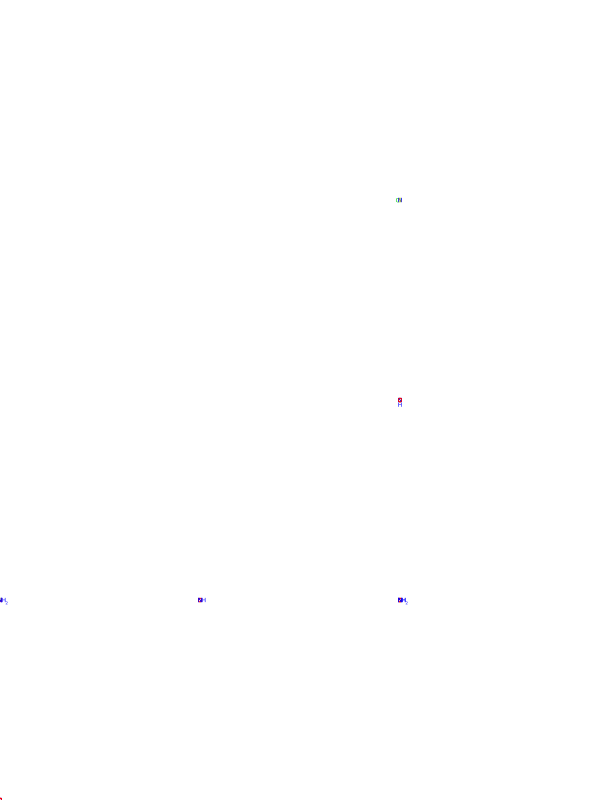

In [16]:
from rdkit.Chem import Draw
from rdkit import Chem
mols=[Chem.MolFromSmiles(s) for s in sm]
Draw.MolsToGridImage(mols)

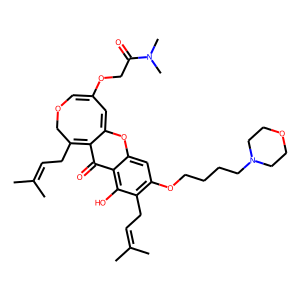

In [26]:
Draw.MolToImage(Chem.MolFromSmiles(sm[9]))

In [3]:
import pandas as pd

In [4]:
pd.__version__

'1.2.3'